Ref_MJD      MJD_(Post Fit)  Uncertainty   MJD

48.26349748	48.26934531	0.0020472	57911.04869

48.26349748	48.25978709	0.0044756	58043.7668

48.26349748	48.26531106	0.0008907	58084.76199

48.26349748	48.26754244	0.00188	58102.53771

48.26349748	48.27399384	0.00079685	58809.57993

48.26349748	48.28131141	0.0050169	58840.4958

48.26349748	48.28104908	0.024016	58846.5017

48.26349748	48.26156537	0.00080149	59168.59384

48.26349748	48.26352621	0.00060989	59181.5515

48.26349748	48.26382735	0.00055025	59211.47439

48.26349748	48.25951189	0.00034787	59246.40244

48.26349748	48.26011367	0.0009144	59286.30253

48.26349748	48.2595234	0.00062206	59345.10692

48.26349748	48.25857703	0.00040442	59365.05278

48.26349748	48.2597705	0.00030842	59392.97623

48.26349748	48.26251471	0.00052887	59428.8913

48.26349748	48.26317891	0.00037814	59468.75364

48.26349748	48.26314167	0.00038503	59518.62765

48.26349748	48.26455084	0.00050353	59547.54228

48.26349748	48.26444901	0.00073053	59582.45814

48.26349748	48.26543432	0.00063644	59693.13549

48.26349748	48.26507574	0.00061919	59727.04777

48.26349748	48.26492041	0.0006833	59792.88659

48.26349748	48.26192045	0.00060555	59822.84678

48.26349748	48.26359066	0.0011673	59834.7672

48.26349748	48.2679896	0.0086138	59882.59584

48.26349748	48.26535216	0.00056624	60101.01073

48.26349748	48.26546589	0.00054602	60147.88145

48.26349748	48.26583963	0.00037655	60191.74688

Point is removed Due to high error;
48.26349748	48.28104908	0.024016	58846.5017

48.26349748	48.2679896	0.0086138	59882.59584


Is in the format of DM_ref DM (Post Fit) Difference (Error) MJD

J0248+4230_pa_550_200_4096_4_1_8_date.raw.gptool.29dec_550_PSR_0248+4230.pfd


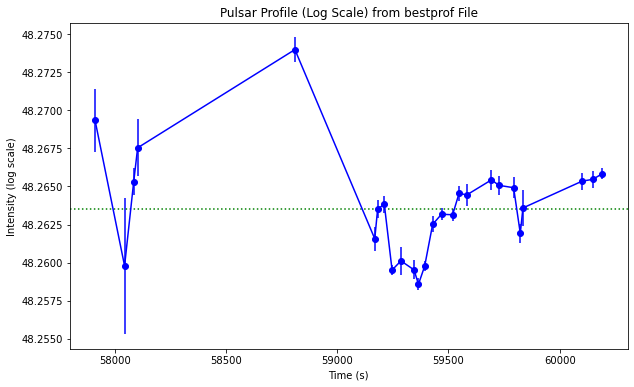

In [10]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt 


# Example assuming a simple text-based format
file_path = '/home/ssahoo/Desktop/Project_2/code/J0248_DM_Fit.txt'

# Read the file
data = np.loadtxt(file_path)

# Assuming the first column is time and the second column is intensity
#time = data[:, 0]
MJD = data[:, 3]
error = data[:, 2]
DM = data[:, 1]

plt.figure(figsize=(10, 6))
plt.errorbar(MJD, DM,  yerr=error, fmt='o', label='Post Fit DM', linestyle='-', color='blue')

reference_dm = 48.26349748
plt.axhline(reference_dm, color='green', linestyle=':', label=f'Reference DM = {reference_dm}')

plt.xlabel('Time (s)')
plt.ylabel('Intensity (log scale)')
plt.title('Pulsar Profile (Log Scale) from bestprof File')
plt.show()

Adding Curve Fit

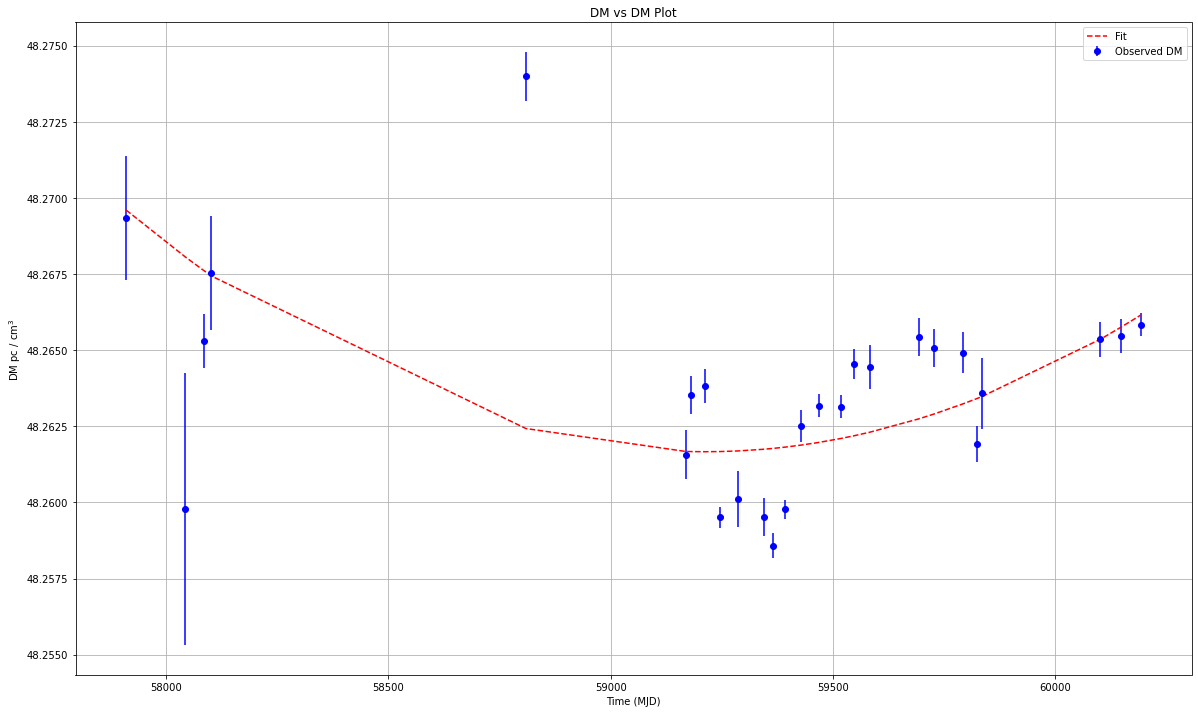

In [19]:


# Define a function for the curve fit (quadratic)
def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

# Perform the curve fit
popt, pcov = curve_fit(quadratic, MJD, DM, sigma=error, absolute_sigma=True)

# Extract the fitted parameters
a, b, c = popt

# Generate fitted data
fitted_DM = quadratic(MJD, a, b, c)

# Plotting the data and the fit
plt.figure(figsize=(20, 12))

# Data with error bars
plt.errorbar(MJD, DM, yerr=error, fmt='o', label='Observed DM', color='blue')

# Fitted curve
plt.plot(MJD, fitted_DM, label='Fit', color='red', linestyle='--')

# reference_dm = 48.26349748
# plt.axhline(reference_dm, color='green', linestyle=':', label=f'Reference DM = {reference_dm}')

# Customize the plot
plt.xlabel('Time (MJD)')
plt.ylabel('DM pc / $cm^3$')
plt.title('DM vs DM Plot')
plt.legend()
plt.grid()
plt.show()


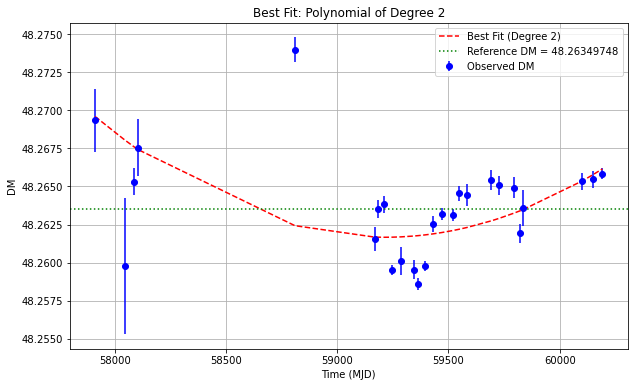

Best fit polynomial degree: 2
Fitted coefficients: [ 6.46814285e+01 -5.54602360e-04  4.68313357e-09]
Reduced Chi-square: 21.700267397012915


In [12]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# File path
file_path = '/home/ssahoo/Desktop/Project_2/code/J0248_DM_Fit.txt'

# Read the file
data = np.loadtxt(file_path)

# Extract columns from data
MJD = data[:, 3]  # Modify if columns differ
error = data[:, 2]
DM = data[:, 1]

# Define a list of polynomial functions
def polynomial(x, *coeffs):
    return sum(c * x**i for i, c in enumerate(coeffs))

# Iteratively fit polynomials of increasing degree
best_degree = None
best_popt = None
best_chi2 = float('inf')
degrees = range(1, 6)  # Test polynomial degrees 1 (linear) to 5
for degree in degrees:
    initial_guess = [1] * (degree + 1)  # Initial guess for coefficients
    try:
        popt, pcov = curve_fit(lambda x, *params: polynomial(x, *params), MJD, DM, p0=initial_guess, sigma=error, absolute_sigma=True)
        residuals = DM - polynomial(MJD, *popt)
        chi2 = np.sum((residuals / error)**2) / (len(DM) - len(popt))  # Reduced chi-square
        
        if chi2 < best_chi2:  # Update if this fit is better
            best_chi2 = chi2
            best_popt = popt
            best_degree = degree
    except RuntimeError:
        continue

# Generate best-fit data
fitted_DM = polynomial(MJD, *best_popt)

# Plotting the data and the best fit
plt.figure(figsize=(10, 6))

# Data with error bars
plt.errorbar(MJD, DM, yerr=error, fmt='o', label='Observed DM', color='blue')

# Best-fit curve
plt.plot(MJD, fitted_DM, label=f'Best Fit (Degree {best_degree})', color='red', linestyle='--')

reference_dm = 48.26349748
plt.axhline(reference_dm, color='green', linestyle=':', label=f'Reference DM = {reference_dm}')

# Customize the plot
plt.xlabel('Time (MJD)')
plt.ylabel('DM')
plt.title(f'Best Fit: Polynomial of Degree {best_degree}')
plt.legend()
plt.grid()
plt.show()

# Print results
print(f"Best fit polynomial degree: {best_degree}")
print(f"Fitted coefficients: {best_popt}")
print(f"Reduced Chi-square: {best_chi2}")


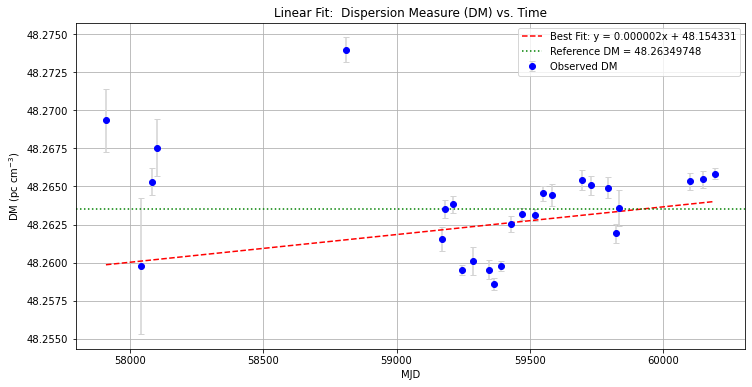

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data from the user
reference_dm = 48.26349748
data = np.array([
    [48.26349748, 48.26934531, 0.0020472, 57911.04869],
    [48.26349748, 48.25978709, 0.0044756, 58043.7668],
    [48.26349748, 48.26531106, 0.0008907, 58084.76199],
    [48.26349748, 48.26754244, 0.00188, 58102.53771],
    [48.26349748, 48.27399384, 0.00079685, 58809.57993],
    [48.26349748, 48.26156537, 0.00080149, 59168.59384],
    [48.26349748, 48.26352621, 0.00060989, 59181.5515],
    [48.26349748, 48.26382735, 0.00055025, 59211.47439],
    [48.26349748, 48.25951189, 0.00034787, 59246.40244],
    [48.26349748, 48.26011367, 0.0009144, 59286.30253],
    [48.26349748, 48.2595234, 0.00062206, 59345.10692],
    [48.26349748, 48.25857703, 0.00040442, 59365.05278],
    [48.26349748, 48.2597705, 0.00030842, 59392.97623],
    [48.26349748, 48.26251471, 0.00052887, 59428.8913],
    [48.26349748, 48.26317891, 0.00037814, 59468.75364],
    [48.26349748, 48.26314167, 0.00038503, 59518.62765],
    [48.26349748, 48.26455084, 0.00050353, 59547.54228],
    [48.26349748, 48.26444901, 0.00073053, 59582.45814],
    [48.26349748, 48.26543432, 0.00063644, 59693.13549],
    [48.26349748, 48.26507574, 0.00061919, 59727.04777],
    [48.26349748, 48.26492041, 0.0006833, 59792.88659],
    [48.26349748, 48.26192045, 0.00060555, 59822.84678],
    [48.26349748, 48.26359066, 0.0011673, 59834.7672],
    [48.26349748, 48.26535216, 0.00056624, 60101.01073],
    [48.26349748, 48.26546589, 0.00054602, 60147.88145],
    [48.26349748, 48.26583963, 0.00037655, 60191.74688],
])

# Extract columns
DM_obs = data[:, 1]
errors = data[:, 2]
MJD = data[:, 3]

# Define a linear function for the fit
def linear_fit(x, m, c):
    return m * x + c

# Perform the curve fitting
popt, pcov = curve_fit(linear_fit, MJD, DM_obs, sigma=errors, absolute_sigma=True)
m, c = popt

# Generate fitted DM values
DM_fit = linear_fit(MJD, m, c)

# Plot the data and the best fit
plt.figure(figsize=(12, 6))
plt.errorbar(MJD, DM_obs, yerr=errors, fmt='o', label='Observed DM', color='blue', ecolor='lightgray', capsize=3)
plt.plot(MJD, DM_fit, label=f'Best Fit: y = {m:.6f}x + {c:.6f}', color='red', linestyle='--')
plt.axhline(reference_dm, color='green', linestyle=':', label=f'Reference DM = {reference_dm}')
plt.xlabel('MJD')
plt.ylabel('DM (pc cm$^{-3}$)')
plt.title('Linear Fit:  Dispersion Measure (DM) vs. Time')
plt.legend()
plt.grid()
plt.show()

